# **Data Challenge: Crop Mapping using remote sensing data and machine learning techniques ***

---

**By Musbaudeen Ibrahim Olaitan**

In [ ]:
#Importing required library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

## **Step 1** :Loading the dataset


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ReSAKSS data challenge/Data - 2024 ReSAKSS Data Challenge/real_Dataset_Sen_GB_Challenge.csv')

## **Step 2**: Exploring the dataset

In [ ]:
type(data)

pandas.core.frame.DataFrame

In [ ]:
data.shape

(205, 50)

## **Note:**
**We have 205 rows and 58 columns**

In [ ]:
data.columns

Index(['Pixel_Id', 'BLUE_2023-07-31', 'GREEN_2023-07-31', 'RED_2023-07-31',
       'NIR_2023-07-31', 'WDRVI_2023-07-31', 'NDVI_2023-07-31',
       'MTCI_2023-07-31', 'SNDVI_2023-07-31', 'CI_2023-07-31',
       'PSRI_2023-07-31', 'EVI_2023-07-31', 'SAVI_2023-07-31',
       'BLUE_2023-08-15', 'GREEN_2023-08-15', 'RED_2023-08-15',
       'NIR_2023-08-15', 'WDRVI_2023-08-15', 'NDVI_2023-08-15',
       'MTCI_2023-08-15', 'SNDVI_2023-08-15', 'CI_2023-08-15',
       'PSRI_2023-08-15', 'EVI_2023-08-15', 'SAVI_2023-08-15',
       'BLUE_2023-09-29', 'GREEN_2023-09-29', 'RED_2023-09-29',
       'NIR_2023-09-29', 'WDRVI_2023-09-29', 'NDVI_2023-09-29',
       'MTCI_2023-09-29', 'SNDVI_2023-09-29', 'CI_2023-09-29',
       'PSRI_2023-09-29', 'EVI_2023-09-29', 'SAVI_2023-09-29',
       'BLUE_2023-10-29', 'GREEN_2023-10-29', 'RED_2023-10-29',
       'NIR_2023-10-29', 'WDRVI_2023-10-29', 'NDVI_2023-10-29',
       'MTCI_2023-10-29', 'SNDVI_2023-10-29', 'CI_2023-10-29',
       'PSRI_2023-10-29', 'EVI_2023

In [ ]:
data.head()

,Pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,NIR_2023-10-29,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Crop_type
0,34,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.372732,0.875462,0.768448,2.869312,0.556969,-0.768448,0.075796,2.827400,0.234310,Arachide - Niebe
1,48,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.337007,0.495436,0.553871,1.938547,0.404286,-0.553871,0.153614,2.785590,0.171345,Mil - Mais
2,281,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.420897,0.614417,0.625980,2.809808,0.476603,-0.625980,0.111767,2.803933,0.211072,Arachide
3,133,0.147460,0.215025,0.288520,0.383439,0.087776,0.142260,1.622770,0.114694,-0.142260,...,0.383206,0.508495,0.566922,1.944712,0.426843,-0.566922,0.108322,2.799167,0.186673,Arachide
4,191,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.322372,0.510028,0.566632,2.360044,0.407864,-0.566632,0.163160,2.787706,0.170481,Mais


In [ ]:
#Exploring the crop_type in the dataset
data['Crop_type'].unique()

array(['Arachide - Niebe', 'Mil - Mais', 'Arachide', 'Mais', 'Mil',
       'Mil - Sorgho', 'Pasteque', 'Verger', 'Niebe', 'Sorgho', 'Oseille'],
      dtype=object)

In [ ]:
#Cleaning the Crop_type column in the dataset, all data input that has Arachide-Niebe should be represented as Groundnut
data['Crop_type'].replace('Arachide - Niebe', 'Groundnut', inplace=True)
data['Crop_type'].replace('Arachide', 'Groundnut', inplace=True)
data['Crop_type'].replace('Niebe', 'Groundnut', inplace=True)

In [ ]:
data.head()

,Pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,NIR_2023-10-29,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Crop_type
0,34,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.372732,0.875462,0.768448,2.869312,0.556969,-0.768448,0.075796,2.827400,0.234310,Groundnut
1,48,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.337007,0.495436,0.553871,1.938547,0.404286,-0.553871,0.153614,2.785590,0.171345,Mil - Mais
2,281,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.420897,0.614417,0.625980,2.809808,0.476603,-0.625980,0.111767,2.803933,0.211072,Groundnut
3,133,0.147460,0.215025,0.288520,0.383439,0.087776,0.142260,1.622770,0.114694,-0.142260,...,0.383206,0.508495,0.566922,1.944712,0.426843,-0.566922,0.108322,2.799167,0.186673,Groundnut
4,191,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.322372,0.510028,0.566632,2.360044,0.407864,-0.566632,0.163160,2.787706,0.170481,Mais


In [ ]:
data['Crop_type'].unique()

array(['Groundnut', 'Mil - Mais', 'Mais', 'Mil', 'Mil - Sorgho',
       'Pasteque', 'Verger', 'Sorgho', 'Oseille'], dtype=object)

In [ ]:
data['Crop_type'].replace('Pasteque', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Oseille', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Sorgho', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Mil - Sorgho', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Mil', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Mil - Mais', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Verger', 'Not groundnut', inplace=True)
data['Crop_type'].replace('Mais', 'Not groundnut', inplace=True)


In [ ]:
data['Crop_type'].unique()

array(['Groundnut', 'Not groundnut'], dtype=object)

In [ ]:
data.head()

,Pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,NIR_2023-10-29,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Crop_type
0,34,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.372732,0.875462,0.768448,2.869312,0.556969,-0.768448,0.075796,2.827400,0.234310,Groundnut
1,48,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.337007,0.495436,0.553871,1.938547,0.404286,-0.553871,0.153614,2.785590,0.171345,Not groundnut
2,281,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.420897,0.614417,0.625980,2.809808,0.476603,-0.625980,0.111767,2.803933,0.211072,Groundnut
3,133,0.147460,0.215025,0.288520,0.383439,0.087776,0.142260,1.622770,0.114694,-0.142260,...,0.383206,0.508495,0.566922,1.944712,0.426843,-0.566922,0.108322,2.799167,0.186673,Groundnut
4,191,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.322372,0.510028,0.566632,2.360044,0.407864,-0.566632,0.163160,2.787706,0.170481,Not groundnut


In [ ]:
#Now we want to convert the crop_type column data to numeral representation, where groundnut is represented as (1) and Not groundnut is represented by (0)
data['Crop_type'].replace('Groundnut', 1, inplace=True)
data['Crop_type'].replace('Not groundnut', 0, inplace=True)


In [ ]:
data.head()

,Pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,NIR_2023-10-29,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Crop_type
0,34,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.372732,0.875462,0.768448,2.869312,0.556969,-0.768448,0.075796,2.827400,0.234310,1
1,48,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.337007,0.495436,0.553871,1.938547,0.404286,-0.553871,0.153614,2.785590,0.171345,0
2,281,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.420897,0.614417,0.625980,2.809808,0.476603,-0.625980,0.111767,2.803933,0.211072,1
3,133,0.147460,0.215025,0.288520,0.383439,0.087776,0.142260,1.622770,0.114694,-0.142260,...,0.383206,0.508495,0.566922,1.944712,0.426843,-0.566922,0.108322,2.799167,0.186673,1
4,191,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.322372,0.510028,0.566632,2.360044,0.407864,-0.566632,0.163160,2.787706,0.170481,0


**HINT**

Now we have cleaned our dataset and we have converted our crop_types column to numeric representation where Groundnut is represented has (1) and Not groundnut is represneted by (0)

In [ ]:
#Now we want to check the blank cells in ur data

data.isna().sum()

Pixel_Id            0
BLUE_2023-07-31     0
GREEN_2023-07-31    0
RED_2023-07-31      0
NIR_2023-07-31      0
WDRVI_2023-07-31    0
NDVI_2023-07-31     0
MTCI_2023-07-31     0
SNDVI_2023-07-31    0
CI_2023-07-31       0
PSRI_2023-07-31     0
EVI_2023-07-31      0
SAVI_2023-07-31     0
BLUE_2023-08-15     0
GREEN_2023-08-15    0
RED_2023-08-15      0
NIR_2023-08-15      0
WDRVI_2023-08-15    0
NDVI_2023-08-15     0
MTCI_2023-08-15     0
SNDVI_2023-08-15    0
CI_2023-08-15       0
PSRI_2023-08-15     0
EVI_2023-08-15      0
SAVI_2023-08-15     0
BLUE_2023-09-29     0
GREEN_2023-09-29    0
RED_2023-09-29      0
NIR_2023-09-29      0
WDRVI_2023-09-29    0
NDVI_2023-09-29     0
MTCI_2023-09-29     0
SNDVI_2023-09-29    0
CI_2023-09-29       0
PSRI_2023-09-29     0
EVI_2023-09-29      0
SAVI_2023-09-29     0
BLUE_2023-10-29     0
GREEN_2023-10-29    0
RED_2023-10-29      0
NIR_2023-10-29      0
WDRVI_2023-10-29    0
NDVI_2023-10-29     0
MTCI_2023-10-29     0
SNDVI_2023-10-29    0
CI_2023-10

# **Insight**
We can see that there is no blank cells in the columns of our dataset, Now we are goo to go for our third step which is step 3

# **STEP 3**: Data modelling and prediction with continous data

In [ ]:
data.columns

Index(['Pixel_Id', 'BLUE_2023-07-31', 'GREEN_2023-07-31', 'RED_2023-07-31',
       'NIR_2023-07-31', 'WDRVI_2023-07-31', 'NDVI_2023-07-31',
       'MTCI_2023-07-31', 'SNDVI_2023-07-31', 'CI_2023-07-31',
       'PSRI_2023-07-31', 'EVI_2023-07-31', 'SAVI_2023-07-31',
       'BLUE_2023-08-15', 'GREEN_2023-08-15', 'RED_2023-08-15',
       'NIR_2023-08-15', 'WDRVI_2023-08-15', 'NDVI_2023-08-15',
       'MTCI_2023-08-15', 'SNDVI_2023-08-15', 'CI_2023-08-15',
       'PSRI_2023-08-15', 'EVI_2023-08-15', 'SAVI_2023-08-15',
       'BLUE_2023-09-29', 'GREEN_2023-09-29', 'RED_2023-09-29',
       'NIR_2023-09-29', 'WDRVI_2023-09-29', 'NDVI_2023-09-29',
       'MTCI_2023-09-29', 'SNDVI_2023-09-29', 'CI_2023-09-29',
       'PSRI_2023-09-29', 'EVI_2023-09-29', 'SAVI_2023-09-29',
       'BLUE_2023-10-29', 'GREEN_2023-10-29', 'RED_2023-10-29',
       'NIR_2023-10-29', 'WDRVI_2023-10-29', 'NDVI_2023-10-29',
       'MTCI_2023-10-29', 'SNDVI_2023-10-29', 'CI_2023-10-29',
       'PSRI_2023-10-29', 'EVI_2023

In [ ]:
x= data [['Pixel_Id', 'BLUE_2023-07-31', 'GREEN_2023-07-31', 'RED_2023-07-31',
       'NIR_2023-07-31', 'WDRVI_2023-07-31', 'NDVI_2023-07-31',
       'MTCI_2023-07-31', 'SNDVI_2023-07-31', 'CI_2023-07-31',
       'PSRI_2023-07-31', 'EVI_2023-07-31', 'SAVI_2023-07-31',
       'BLUE_2023-08-15', 'GREEN_2023-08-15', 'RED_2023-08-15',
       'NIR_2023-08-15', 'WDRVI_2023-08-15', 'NDVI_2023-08-15',
       'MTCI_2023-08-15', 'SNDVI_2023-08-15', 'CI_2023-08-15',
       'PSRI_2023-08-15', 'EVI_2023-08-15', 'SAVI_2023-08-15',
       'BLUE_2023-09-29', 'GREEN_2023-09-29', 'RED_2023-09-29',
       'NIR_2023-09-29', 'WDRVI_2023-09-29', 'NDVI_2023-09-29',
       'MTCI_2023-09-29', 'SNDVI_2023-09-29', 'CI_2023-09-29',
       'PSRI_2023-09-29', 'EVI_2023-09-29', 'SAVI_2023-09-29',
       'BLUE_2023-10-29', 'GREEN_2023-10-29', 'RED_2023-10-29',
       'NIR_2023-10-29', 'WDRVI_2023-10-29', 'NDVI_2023-10-29',
       'MTCI_2023-10-29', 'SNDVI_2023-10-29', 'CI_2023-10-29',
       'PSRI_2023-10-29', 'EVI_2023-10-29', 'SAVI_2023-10-29']]

y= data ['Crop_type']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
#data scaling
scaler = StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
accuracy_list =[] #This is a list to save all the values from different models accuracy for comparison using a bar chart

# **3.1 Logistics Regression**

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(x_train_scaled, y_train)
lr_prediction = lr_model.predict(x_test_scaled)
lr_accuracy =(round(accuracy_score(lr_prediction, y_test), 4) *100) #percentage
accuracy_list.append(lr_accuracy)

# **3.2 Support Vector Machine**

In [ ]:
svc_model = SVC()
svc_model.fit(x_train_scaled, y_train)
svc_prediction = svc_model.predict(x_test_scaled)
svc_accuracy= (round(accuracy_score(svc_prediction, y_test), 4) *100) #percentage
accuracy_list.append(svc_accuracy)

# **3.3 Decision Tree Classifier**

In [ ]:
dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=2)
dt_model.fit(x_train_scaled, y_train)
dt_prediction= dt_model.predict(x_test_scaled)
dt_accuracy= (round(accuracy_score(dt_prediction, y_test), 4) *100) #percentage
accuracy_list.append(dt_accuracy)

# **3.4 Naive Bayes**

In [ ]:
nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)
nb_prediction= nb_model.predict(x_test_scaled)
nb_accuracy= (round(accuracy_score(nb_prediction, y_test), 4) *100) #percentage
accuracy_list.append(nb_accuracy)

# **3.5 Random Forest Classifier**

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train_scaled, y_train)
rf_prediction= rf_model.predict(x_test_scaled)
rf_accuracy= (round(accuracy_score(rf_prediction, y_test), 4) *100) #percentage
accuracy_list.append(rf_accuracy)

# **3.6 Gradient Boosting Machines**

In [ ]:
#model for Gradient Boosting Machines
gb_model = GradientBoostingClassifier()
gb_model.fit(x_train_scaled, y_train)
gb_prediction= gb_model.predict(x_test_scaled) # Call predict to get predicted values
gb_accuracy= (round(accuracy_score(gb_prediction, y_test), 4) *100) #percentage
accuracy_list.append(gb_accuracy)

In [ ]:
accuracy_list

[51.92,
 55.769999999999996,
 55.769999999999996,
 51.92,
 53.849999999999994,
 61.53999999999999]

In [ ]:
models = ['Logistic Regression', 'Support Vector Machine', 'Decision Tree Classifier', 'Naive Bayes', 'Random Forest Classifier', 'Gradient Boosting Machines']

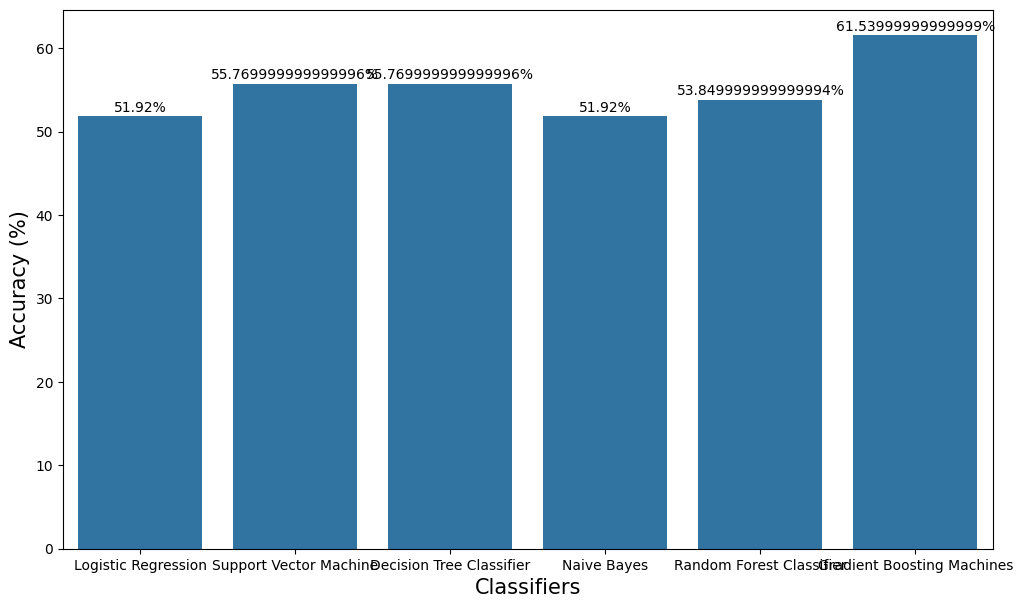

In [ ]:

plt.figure(figsize=(12,7))
ax = sns.barplot(x=models, y=accuracy_list)
plt.xlabel("Classifiers", fontsize=15)
plt.ylabel("Accuracy (%)", fontsize=15)
for p in ax.patches:
  width = p.get_width()
  height = p.get_height()
  x=p.get_x()
  y=p.get_y()
  ax.annotate(f"{height}%", (x + width/2, y + height*1.01), ha="center")
plt.show()

In [ ]:
#Test prediction with challenge data to ascertain the reliability
input_data = (
258,0.8186147616497051,0.7346537546866632,0.6781677557579003,0.6901555865024099,0.0049166041775093,0.0087806230261775,-0.8418684361047069,0.0078594824250401,-0.0087806230261775,-0.2034735142690872,2.440855497713716,0.0042845385113276,0.0788711515800749,0.1400515050883771,0.1231240921264059,0.4226379860739153,0.4936368352549426,0.5523086893031933,2.3265352546525566,0.4263532760769601,-0.5523086893031933,0.1049034649476704,2.793559708630265,0.1914915241631071,0.0461433047670058,0.1022443706480985,0.0800460632029994,0.3647649276914836,0.6545499171043071,0.6444320613926612,2.3434333203797424,0.4728639563975316,-0.6444320613926612,0.0941306499242197,2.800549368573695,0.2014096377190631,0.0502283663631494,0.0924502517407605,0.0718246063202999,0.3639855168719871,0.6817941381582389,0.671185212473161,2.5658593734877067,0.4906538881523895,-0.671185212473161,0.0598574124329615,2.826332382896477,0.2081781879472908 )
# changing the input_data to numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshaping the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardizing the input data
std_data= scaler.transform(input_data_reshaped)
print(std_data)

prediction = gb_model.predict(std_data)
print(prediction)

if (prediction[0]==1):
  print ("Groundnut")
else:
  print("Not groundnut")

[[ 1.00467644  2.65533609  2.69017965  2.71283193  2.49670117 -1.82501186
  -2.11472636 -2.08959384 -2.27113616  2.11472636 -1.97626463 -0.0965961
  -2.38932287 -0.82371468 -0.74517106 -1.4900511   0.84243217  3.51255621
   3.17497233  0.4719328   3.29879711 -3.17497233 -1.44004239  0.61917782
   3.40023267 -1.09644876 -0.98804189 -1.26254758 -0.72874547  0.91456872
   1.03296239 -0.90781099  0.84976663 -1.03296239 -0.54062913  0.46184537
   0.62921404 -0.27873732 -0.26379082 -0.74231098  0.30941745  0.82275149
   0.85954642  0.26076187  0.87262566 -0.85954642 -1.05896408  0.54397072
   0.84458002]]
[1]
Groundnut


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
df_predict_file = pd.read_csv("/content/drive/MyDrive/ReSAKSS data challenge/Data - 2024 ReSAKSS Data Challenge/real Dataset_Sen_GB_Challenge_to_predict.csv")

In [ ]:
df_predict_file.head()

,pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Unnamed: 49,Crop_type
0,112,0.233848,0.255558,0.284781,0.364195,0.074640,0.123047,0.897172,0.098556,-0.123047,...,0.377531,0.458413,2.143239,0.358334,-0.458413,0.162254,2.767392,0.163356,NaN,NaN
1,315,0.329815,0.315499,0.304012,0.401401,0.086758,0.140441,1.137938,0.113967,-0.140441,...,0.682877,0.656591,3.094342,0.485123,-0.656591,0.079622,2.821872,0.208470,NaN,NaN
2,280,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.402265,0.484623,2.162294,0.355047,-0.484623,0.191757,2.775192,0.151084,NaN,NaN
3,172,0.108518,0.169077,0.240833,0.321205,0.088632,0.143721,1.193662,0.111642,-0.143721,...,0.490029,0.553340,1.795443,0.411808,-0.553340,0.110066,2.794265,0.177920,NaN,NaN
4,223,0.264843,0.300006,0.324860,0.435007,0.090253,0.146056,0.713731,0.120416,-0.146056,...,0.743392,0.702047,2.710365,0.526788,-0.702047,0.062646,2.828433,0.229547,NaN,NaN


In [ ]:
#Deleting column titled Unnamed: 49 from the df_predict_file
del df_predict_file['Unnamed: 49']


In [ ]:
df_predict_file.head()

,pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,NIR_2023-10-29,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Crop_type
0,112,0.233848,0.255558,0.284781,0.364195,0.074640,0.123047,0.897172,0.098556,-0.123047,...,0.426349,0.377531,0.458413,2.143239,0.358334,-0.458413,0.162254,2.767392,0.163356,NaN
1,315,0.329815,0.315499,0.304012,0.401401,0.086758,0.140441,1.137938,0.113967,-0.140441,...,0.379200,0.682877,0.656591,3.094342,0.485123,-0.656591,0.079622,2.821872,0.208470,NaN
2,280,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.328332,0.402265,0.484623,2.162294,0.355047,-0.484623,0.191757,2.775192,0.151084,NaN
3,172,0.108518,0.169077,0.240833,0.321205,0.088632,0.143721,1.193662,0.111642,-0.143721,...,0.362422,0.490029,0.553340,1.795443,0.411808,-0.553340,0.110066,2.794265,0.177920,NaN
4,223,0.264843,0.300006,0.324860,0.435007,0.090253,0.146056,0.713731,0.120416,-0.146056,...,0.410347,0.743392,0.702047,2.710365,0.526788,-0.702047,0.062646,2.828433,0.229547,NaN


In [ ]:
#Deleting column titled Unnamed: 49 from the df_predict_file
del df_predict_file['Crop_type']

In [ ]:
data_list = df_predict_file.values.tolist()

In [ ]:
# Test prediction with challenge data to ascertain the reliability
input_data = data_list

# List to store predictions
predictions_list = []

# Iterate over each set of input data and predict the outcome
for data in input_data:
    # Convert the list to a numpy array
    input_data_as_numpy_array = np.asarray(data)

    # Reshape the array as we are predicting for one instance
    input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

    # Standardize the input data
    std_data = scaler.transform(input_data_reshaped)

    # Make the prediction
    prediction = gb_model.predict(std_data)

    # Append the result to the predictions list
    predictions_list.append(prediction[0])

# Output the list of predictions
print(predictions_list)

# Optionally, convert the numerical predictions to corresponding crop names
crop_names = ["Not groundnut", "Groundnut"]
prediction_labels = [crop_names[p] for p in predictions_list]
print(prediction_labels)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but 

[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0]
['Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Groundnut', 'Groundnut', 'Groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnut', 'Not groundnu

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but 

In [ ]:
df_predict_file.head()

,pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,RED_2023-10-29,NIR_2023-10-29,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29
0,112,0.233848,0.255558,0.284781,0.364195,0.074640,0.123047,0.897172,0.098556,-0.123047,...,0.161838,0.426349,0.377531,0.458413,2.143239,0.358334,-0.458413,0.162254,2.767392,0.163356
1,315,0.329815,0.315499,0.304012,0.401401,0.086758,0.140441,1.137938,0.113967,-0.140441,...,0.078313,0.379200,0.682877,0.656591,3.094342,0.485123,-0.656591,0.079622,2.821872,0.208470
2,280,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.114752,0.328332,0.402265,0.484623,2.162294,0.355047,-0.484623,0.191757,2.775192,0.151084
3,172,0.108518,0.169077,0.240833,0.321205,0.088632,0.143721,1.193662,0.111642,-0.143721,...,0.104394,0.362422,0.490029,0.553340,1.795443,0.411808,-0.553340,0.110066,2.794265,0.177920
4,223,0.264843,0.300006,0.324860,0.435007,0.090253,0.146056,0.713731,0.120416,-0.146056,...,0.072044,0.410347,0.743392,0.702047,2.710365,0.526788,-0.702047,0.062646,2.828433,0.229547


In [ ]:
df_predict_file.shape

(95, 49)

In [638]:
df_1= pd.DataFrame(predictions_list, columns=['Crop_type'])
df_2= pd.DataFrame(prediction_labels, columns=['Crop_type_label'])

In [639]:
df_1

,Crop_type
0,0
1,1
2,0
3,0
4,0
...,...
90,1
91,1
92,0
93,0


In [640]:
df_2

,Crop_type_label
0,Not groundnut
1,Groundnut
2,Not groundnut
3,Not groundnut
4,Not groundnut
...,...
90,Groundnut
91,Groundnut
92,Not groundnut
93,Not groundnut


In [641]:
Final_prediction_data= pd.concat([df_predict_file, df_1,df_2], axis=1)

In [642]:
Final_prediction_data

,pixel_Id,BLUE_2023-07-31,GREEN_2023-07-31,RED_2023-07-31,NIR_2023-07-31,WDRVI_2023-07-31,NDVI_2023-07-31,MTCI_2023-07-31,SNDVI_2023-07-31,CI_2023-07-31,...,WDRVI_2023-10-29,NDVI_2023-10-29,MTCI_2023-10-29,SNDVI_2023-10-29,CI_2023-10-29,PSRI_2023-10-29,EVI_2023-10-29,SAVI_2023-10-29,Crop_type,Crop_type_label
0,112,0.233848,0.255558,0.284781,0.364195,0.074640,0.123047,0.897172,0.098556,-0.123047,...,0.377531,0.458413,2.143239,0.358334,-0.458413,0.162254,2.767392,0.163356,0,Not groundnut
1,315,0.329815,0.315499,0.304012,0.401401,0.086758,0.140441,1.137938,0.113967,-0.140441,...,0.682877,0.656591,3.094342,0.485123,-0.656591,0.079622,2.821872,0.208470,1,Groundnut
2,280,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.402265,0.484623,2.162294,0.355047,-0.484623,0.191757,2.775192,0.151084,0,Not groundnut
3,172,0.108518,0.169077,0.240833,0.321205,0.088632,0.143721,1.193662,0.111642,-0.143721,...,0.490029,0.553340,1.795443,0.411808,-0.553340,0.110066,2.794265,0.177920,0,Not groundnut
4,223,0.264843,0.300006,0.324860,0.435007,0.090253,0.146056,0.713731,0.120416,-0.146056,...,0.743392,0.702047,2.710365,0.526788,-0.702047,0.062646,2.828433,0.229547,0,Not groundnut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,7,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.640761,0.649667,2.018687,0.480372,-0.649667,0.127432,2.784781,0.206201,1,Groundnut
91,266,0.271273,0.285991,0.304943,0.394108,0.101009,0.155166,1.328975,0.119395,-0.155166,...,0.309606,0.358615,7.523626,0.270285,-0.358615,0.304397,2.701798,0.118471,1,Groundnut
92,64,0.310633,0.314348,0.321700,0.389051,0.058629,0.097111,0.214606,0.078741,-0.097111,...,0.294605,0.381872,1.572202,0.285073,-0.381872,0.172920,2.756116,0.124033,0,Not groundnut
93,89,0.138139,0.200861,0.280882,0.367995,0.082389,0.134776,1.385642,0.108011,-0.134776,...,0.625620,0.621149,3.135988,0.472924,-0.621149,0.099579,2.809525,0.209283,0,Not groundnut


In [644]:
Final_result= Final_prediction_data[['pixel_Id', 'Crop_type_label']]

In [647]:
Final_result

,pixel_Id,Crop_type_label
0,112,Not groundnut
1,315,Groundnut
2,280,Not groundnut
3,172,Not groundnut
4,223,Not groundnut
...,...,...
90,7,Groundnut
91,266,Groundnut
92,64,Not groundnut
93,89,Not groundnut


In [651]:
df = pd.DataFrame(Final_result)

# Export to Excel
df.to_excel('/content/drive/MyDrive/DATASETS/prediction_result.xlsx', index=False)